# Netflix – Data Exploration & Visualisation

## Business Case Study

**Objective:** Analyze Netflix content to identify patterns that can help guide content production and business growth across countries.

### Key business questions
1. How is Netflix content split between Movies and TV Shows?
2. How has content changed over the last 20–30 years?
3. Has Netflix increased its focus on TV Shows in recent years?
4. What content is available across countries?
5. Which genres, ratings and content formats dominate?
6. Which actors and directors appear most frequently?
7. Which months have the highest number of TV Shows added?
8. What actionable recommendations can be made for Netflix?

## 1. Import libraries and load data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

df = pd.read_csv("netflix.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5398, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020.0,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021.0,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021.0,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021.0,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021.0,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 2. Basic data understanding

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nInformation:")
df.info()

Rows: 5398
Columns: 12

Columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data types:
show_id          object
type             object
title            object
director         object
cast             object
country          object
date_added       object
release_year    float64
rating           object
duration         object
listed_in        object
description      object
dtype: object

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5398 entries, 0 to 5397
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       5398 non-null   object 
 1   type          5398 non-null   object 
 2   title         5397 non-null   object 
 3   director      3515 non-null   object 
 4   cast          4903 non-null   object 
 5   country       4735 non-null   object 
 6   date_added    5397 non-null   object 
 7  

## 3. Missing value detection

In [4]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum()/len(df)*100).round(2)
}).sort_values("Missing Values", ascending=False)
missing

,Missing Values,Missing %
director,1883,34.88
country,663,12.28
cast,495,9.17
title,1,0.02
rating,1,0.02
duration,1,0.02
date_added,1,0.02
release_year,1,0.02
listed_in,1,0.02
description,1,0.02


### Missing-value observation

`director` has the largest number of missing values, followed by `country` and `cast`. Because these are descriptive attributes, deleting all missing rows would unnecessarily reduce the dataset. Missing categorical values will be represented as `Unknown` for analysis.

## 4. Data preprocessing

In [5]:
# Preserve raw data; create an analysis copy
netflix = df.copy()

# Fill missing categorical values
for col in ["director", "cast", "country", "rating", "duration"]:
    netflix[col] = netflix[col].fillna("Unknown")

# Date conversion
netflix["date_added"] = pd.to_datetime(netflix["date_added"], errors="coerce")
netflix["year_added"] = netflix["date_added"].dt.year
netflix["month_added"] = netflix["date_added"].dt.month

# Category conversion where appropriate
for col in ["type", "rating"]:
    netflix[col] = netflix[col].astype("category")

netflix.isnull().sum()

,0
show_id,0
type,0
title,1
director,0
cast,0
country,0
date_added,1
release_year,1
rating,0
duration,0


## 5. Statistical summary

In [6]:
netflix.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
show_id,5398,5398,s5398,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,5398,3,Movie,3464,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,5397,5397,Lal Patthar,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,5398,2722,Unknown,1883,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,5398,4750,Unknown,495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,5398,476,United States,1545,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,5397,NaN,NaN,NaN,2020-02-02 21:51:39.722067712,2017-07-01 00:00:00,2019-03-04 00:00:00,2020-04-09 00:00:00,2021-02-03 00:00:00,2021-09-25 00:00:00,NaN
release_year,5397.0,NaN,NaN,NaN,2016.083936,1925.0,2016.0,2018.0,2020.0,2021.0,7.121457
rating,5398,12,TV-MA,2246,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,5398,209,1 Season,1258,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
netflix["release_year"].describe()

,release_year
count,5397.000000
mean,2016.083936
std,7.121457
min,1925.000000
25%,2016.000000
50%,2018.000000
75%,2020.000000
max,2021.000000


## 6. Non-graphical analysis: unique values and value counts

In [8]:
print("Movie vs TV Show:\n", netflix["type"].value_counts())
print("\nPercentage:\n", (netflix["type"].value_counts(normalize=True)*100).round(2))
print("\nUnique titles:", netflix["title"].nunique())
print("Unique release years:", netflix["release_year"].nunique())
print("\nTop ratings:\n", netflix["rating"].value_counts().head(10))

Movie vs TV Show:
 type
Movie      3464
TV Show    1933
TV Sh         1
Name: count, dtype: int64

Percentage:
 type
Movie      64.17
TV Show    35.81
TV Sh       0.02
Name: proportion, dtype: float64

Unique titles: 5397
Unique release years: 62

Top ratings:
 rating
TV-MA    2246
TV-14    1373
TV-PG     465
R         367
TV-Y      230
PG-13     226
TV-Y7     209
TV-G      144
PG        123
G          13
Name: count, dtype: int64


## 7. Univariate analysis – content type

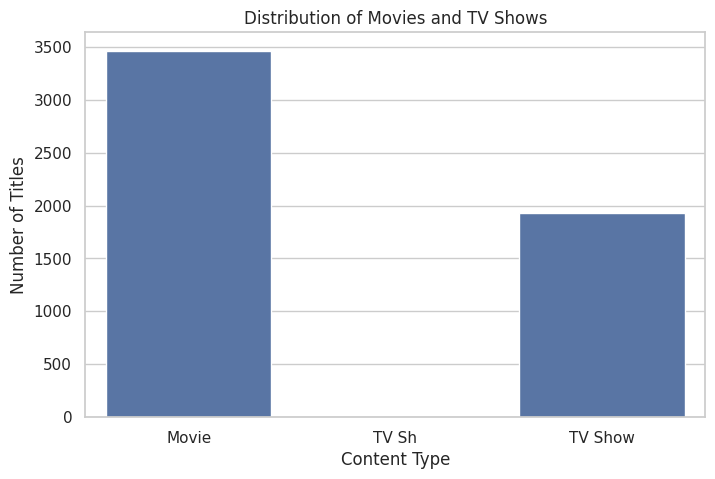

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(data=netflix, x="type", color="C0")
plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

**Observation:** Movies are the majority of the catalog, accounting for about 69.6% of titles, while TV Shows account for about 30.4%.

## 8. Release-year distribution

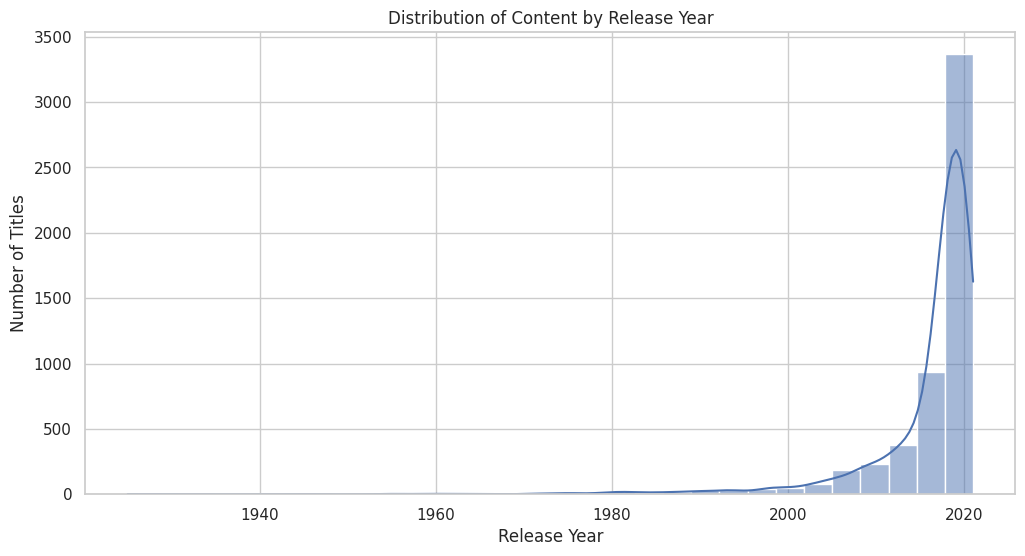

In [10]:
plt.figure(figsize=(12,6))
sns.histplot(data=netflix, x="release_year", bins=30, kde=True, color="C0")
plt.title("Distribution of Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

**Observation:** The distribution is strongly concentrated toward recent releases, especially from the mid-2010s onward. The median release year is 2017.

## 9. Content released per year – last 30 years

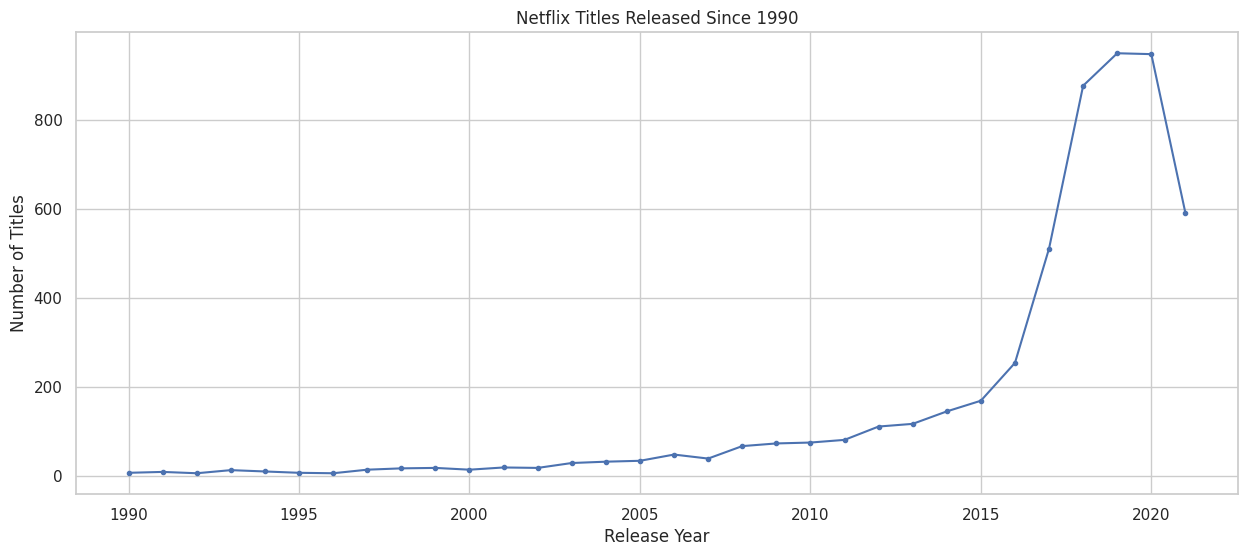

In [11]:
year_counts = netflix["release_year"].value_counts().sort_index()
recent_years = year_counts[year_counts.index >= 1990]

plt.figure(figsize=(15,6))
plt.plot(recent_years.index, recent_years.values, marker="o", markersize=3)
plt.title("Netflix Titles Released Since 1990")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

## 10. Movies vs TV Shows by release year

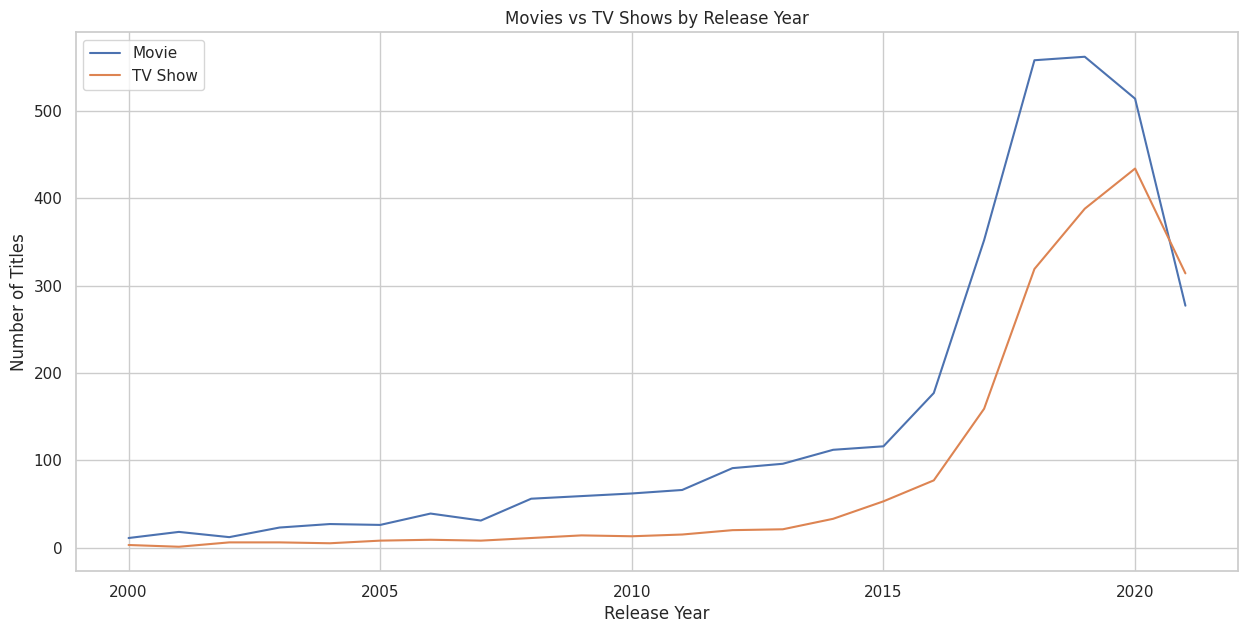

type          Movie  TV Show
release_year                
2017.0          352      159
2018.0          558      319
2019.0          562      388
2020.0          514      434
2021.0          277      314


In [12]:
type_year = pd.crosstab(netflix["release_year"], netflix["type"])
type_year = type_year[type_year.index >= 2000]

plt.figure(figsize=(15,7))
for c in ["Movie", "TV Show"]:
    plt.plot(type_year.index, type_year[c], label=c)
plt.title("Movies vs TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend()
plt.show()

print(type_year.loc[2017:2021])

**Observation:** Movies remain larger overall, but TV Shows have grown faster in the recent period. In the dataset, TV Shows exceed Movies for release year 2021 (315 vs 277), suggesting a stronger recent emphasis on episodic content.

## 11. Has Netflix focused more on TV Shows in recent years?

type
Movie      2263
TV Show    1614
TV Sh         0
Name: count, dtype: int64

Percentages:
 type
Movie      58.37
TV Show    41.63
TV Sh       0.00
Name: proportion, dtype: float64


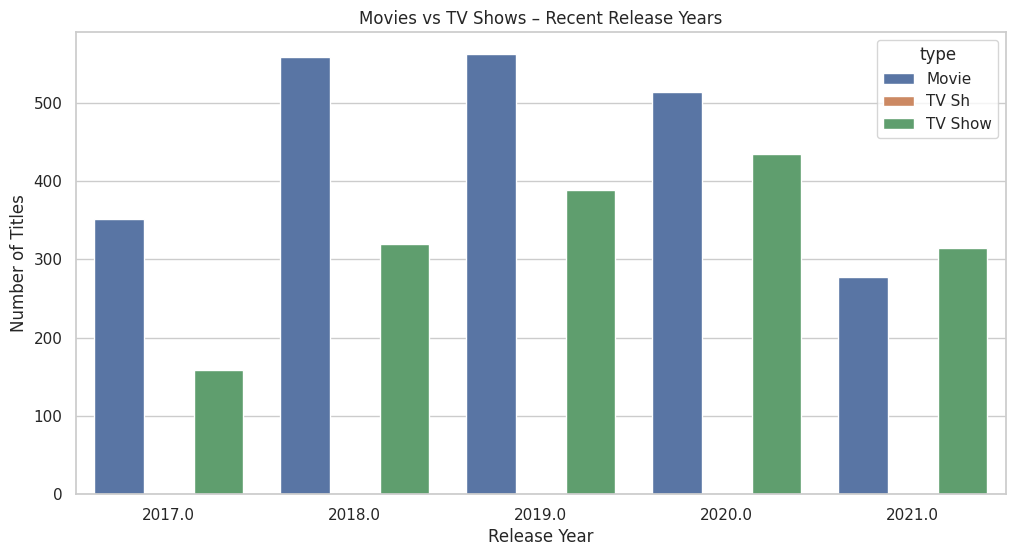

In [13]:
recent = netflix[netflix["release_year"] >= 2017]
print(recent["type"].value_counts())
print("\nPercentages:\n", (recent["type"].value_counts(normalize=True)*100).round(2))

plt.figure(figsize=(12,6))
sns.countplot(data=recent, x="release_year", hue="type", palette="deep")
plt.title("Movies vs TV Shows – Recent Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

## 12. Date-added analysis

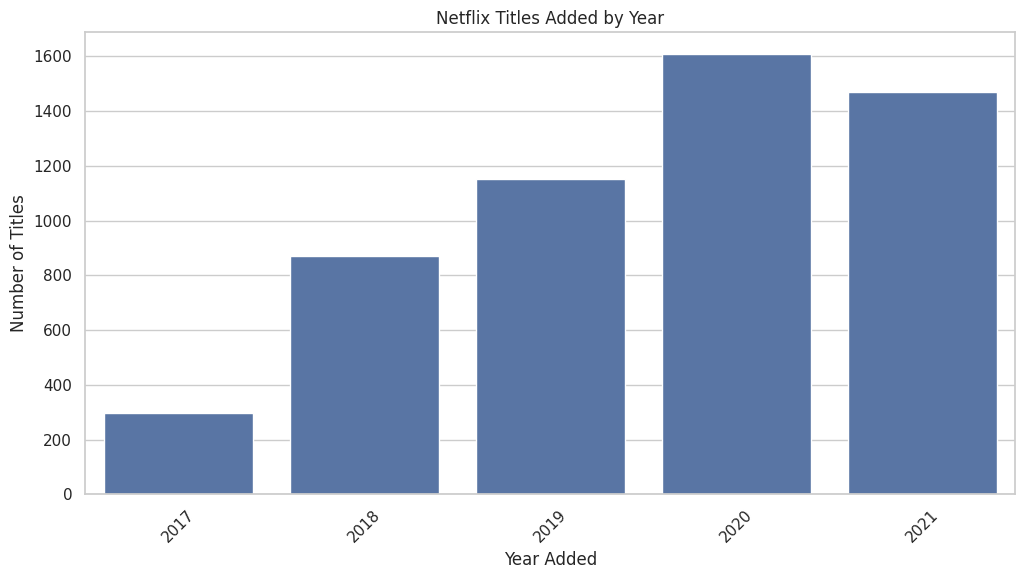

year_added
2017.0     297
2018.0     871
2019.0    1152
2020.0    1607
2021.0    1470
Name: count, dtype: int64


In [14]:
added_year_counts = netflix["year_added"].value_counts().sort_index()
plt.figure(figsize=(12,6))
sns.barplot(x=added_year_counts.index.astype(int), y=added_year_counts.values, color="C0")
plt.title("Netflix Titles Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()
print(added_year_counts)

## 13. Best month to launch/add a TV Show

month_added
January      130
February     120
March        135
April        152
May          142
June         178
July         200
August       186
September    194
October      161
November     172
December     163
Name: count, dtype: int64


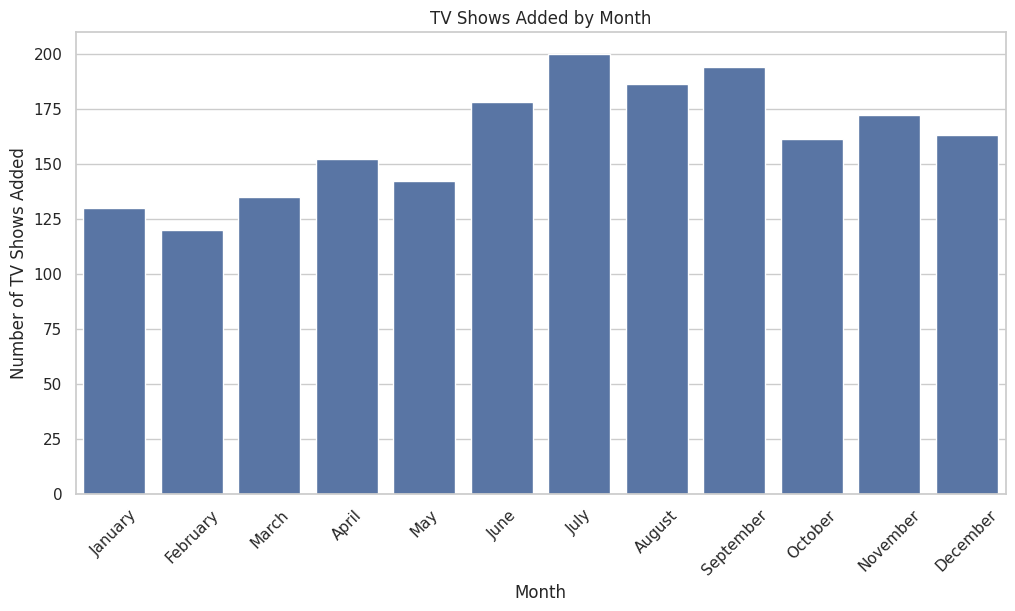

Highest month: July with 200 TV Shows


In [15]:
month_names = {1:"January",2:"February",3:"March",4:"April",5:"May",6:"June",7:"July",8:"August",9:"September",10:"October",11:"November",12:"December"}

tv = netflix[netflix["type"] == "TV Show"].copy()
tv_month = tv["month_added"].value_counts().sort_index()
tv_month_named = tv_month.rename(index=month_names)
print(tv_month_named)

plt.figure(figsize=(12,6))
sns.barplot(x=tv_month_named.index, y=tv_month_named.values, color="C0")
plt.title("TV Shows Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of TV Shows Added")
plt.xticks(rotation=45)
plt.show()

print("Highest month:", tv_month_named.idxmax(), "with", tv_month_named.max(), "TV Shows")

**Business caveat:** July has the highest number of TV Shows added (254). This indicates the most common historical addition period in this dataset, but the dataset does not contain viewership, engagement or subscriber data, so it cannot prove that July produces the best business performance.

## 14. Country analysis – unnesting

country
United States     1999
Unknown            663
India              638
United Kingdom     383
Japan              244
Canada             230
France             225
Spain              166
South Korea        158
Germany            124
Mexico             111
China              101
Nigeria             90
Australia           84
Turkey              76
Name: count, dtype: int64


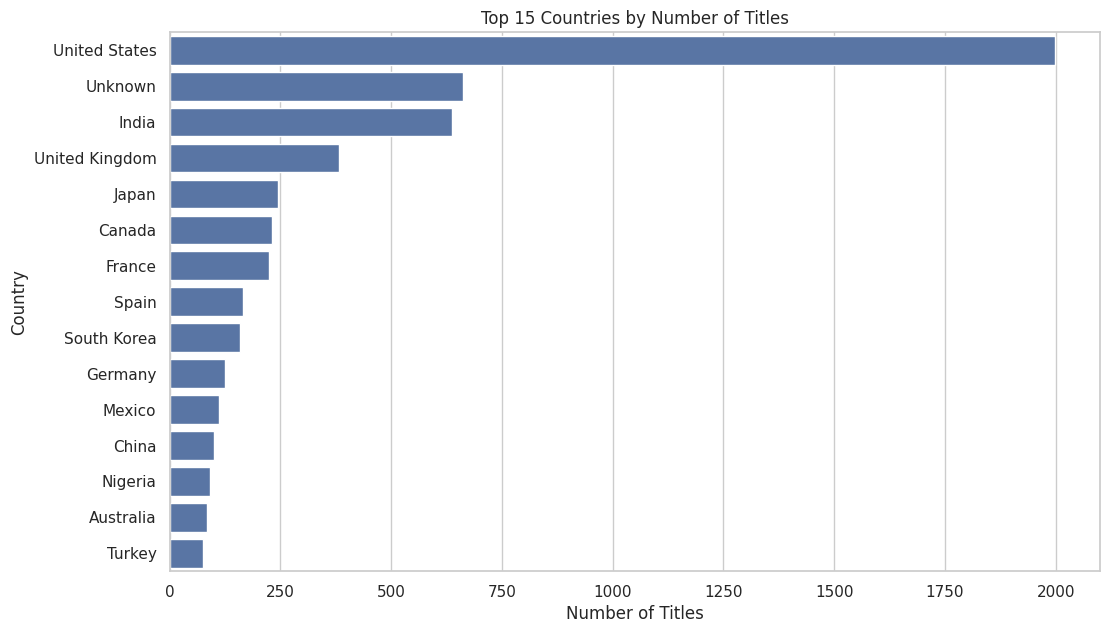

In [16]:
country_df = netflix.copy()
country_df["country"] = country_df["country"].str.split(", ")
country_df = country_df.explode("country")
country_counts = country_df["country"].value_counts()
print(country_counts.head(15))

plt.figure(figsize=(12,7))
top15 = country_counts.head(15)
sns.barplot(x=top15.values, y=top15.index, color="C0")
plt.title("Top 15 Countries by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

## 15. Country × content type

type            Movie  TV Sh  TV Show  Total
country                                     
United States    1302      0      697   3998
Unknown           361      1      301   1326
India             589      0       49   1276
United Kingdom    234      0      149    766
Japan              86      0      158    488
Canada            149      0       81    460
France            163      0       62    450
Spain             116      0       50    332
South Korea        39      0      119    316
Germany            88      0       36    248
Mexico             68      0       43    222
China              63      0       38    202
Nigeria            81      0        9    180
Australia          38      0       46    168
Turkey             61      0       15    152


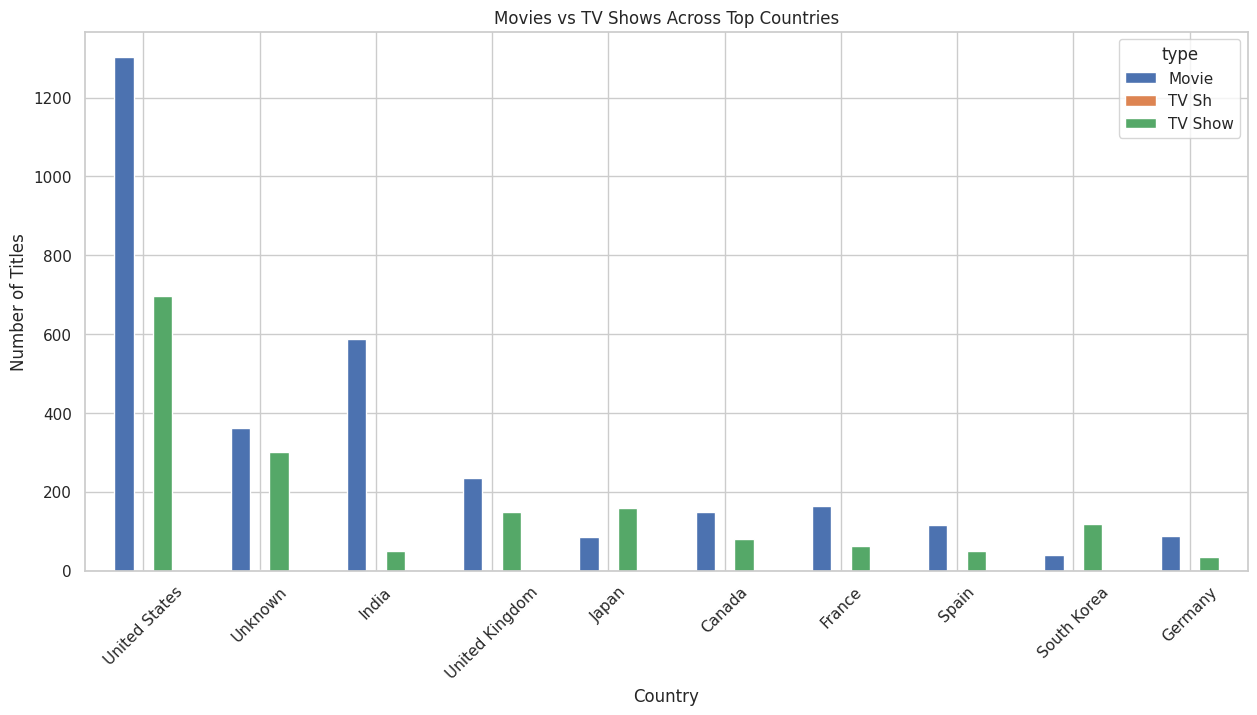

In [17]:
country_type = (
    country_df.assign(country=country_df["country"].fillna("Unknown").str.split(", "))
    .explode("country")
    .groupby(["country", "type"])
    .size()
    .unstack(fill_value=0)
)
country_type["Total"] = country_type.sum(axis=1)
country_type = country_type.sort_values("Total", ascending=False)
country_type["Total"] = country_type.sum(axis=1)
country_type = country_type.sort_values("Total", ascending=False)
print(country_type.head(15))

top = country_type.head(10).drop(columns="Total")
top.plot(kind="bar", figsize=(15,7))
plt.title("Movies vs TV Shows Across Top Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

## 16. Genre analysis – unnesting

listed_in
International Movies        1755
Dramas                      1426
Comedies                    1025
International TV Shows      1000
TV Dramas                    576
Action & Adventure           464
TV Comedies                  436
Romantic Movies              398
Documentaries                389
Children & Family Movies     377
Independent Movies           376
Crime TV Shows               349
Thrillers                    328
Kids' TV                     321
Romantic TV Shows            253
Name: count, dtype: int64


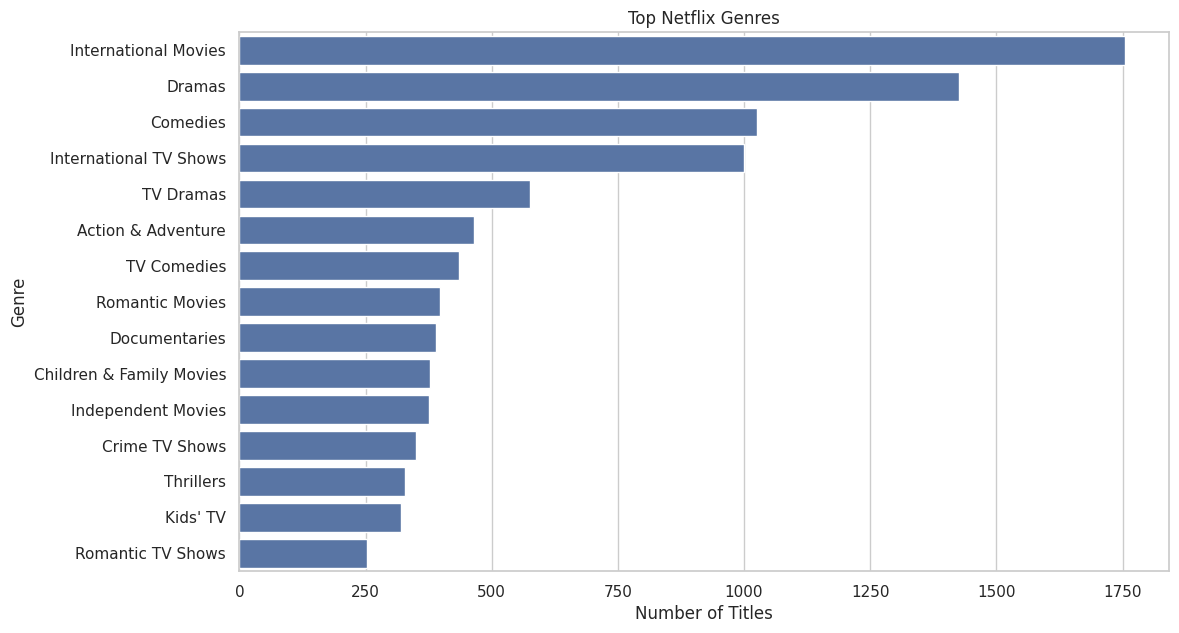

In [18]:
genre_df = netflix.copy()
genre_df["listed_in"] = genre_df["listed_in"].str.split(", ")
genre_df = genre_df.explode("listed_in")
genre_counts = genre_df["listed_in"].value_counts()
print(genre_counts.head(15))

top_genres = genre_counts.head(15)
plt.figure(figsize=(12,7))
sns.barplot(x=top_genres.values, y=top_genres.index, color="C0")
plt.title("Top Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

## 17. Ratings

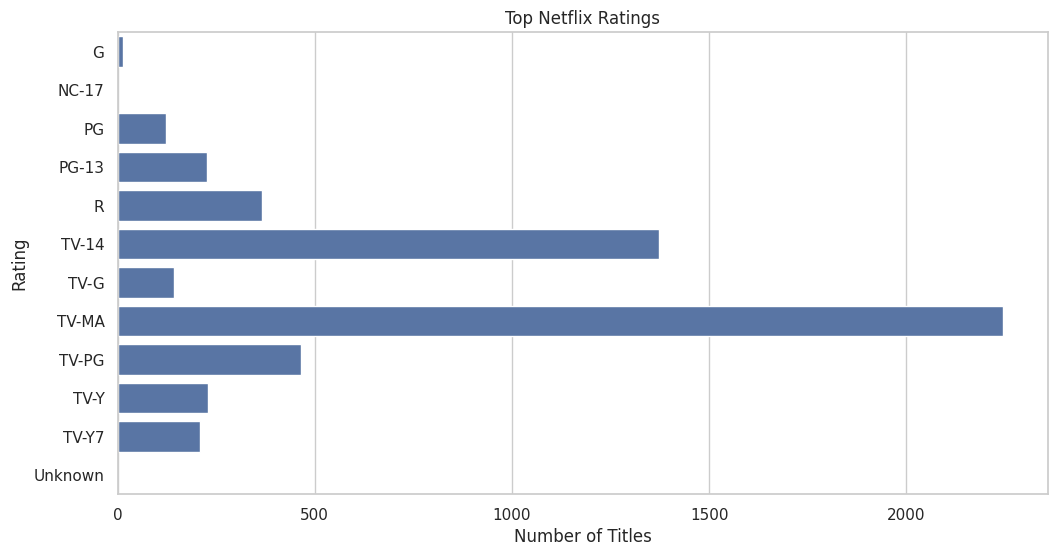

rating
TV-MA    2246
TV-14    1373
TV-PG     465
R         367
TV-Y      230
PG-13     226
TV-Y7     209
TV-G      144
PG        123
G          13
Name: count, dtype: int64


In [19]:
rating_counts = netflix["rating"].value_counts()
plt.figure(figsize=(12,6))
r10 = rating_counts.head(10)
sns.barplot(x=r10.values, y=r10.index, color="C0")
plt.title("Top Netflix Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.show()
print(rating_counts.head(10))

## 18. Movie duration analysis

count    3464.000000
mean      100.387991
std        29.968087
min         3.000000
25%        87.000000
50%       100.000000
75%       116.000000
max       312.000000
Name: duration_minutes, dtype: float64


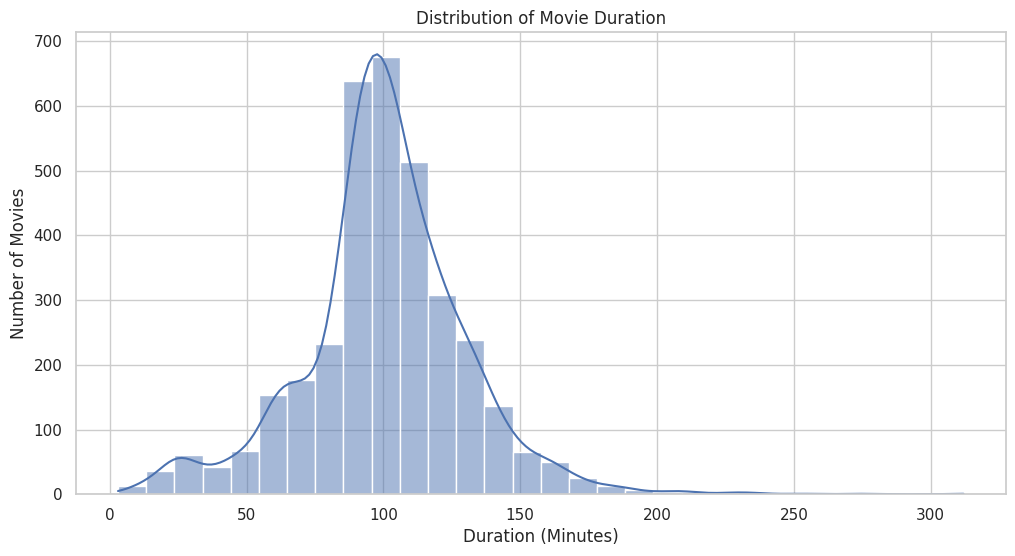

In [20]:
movies = netflix[netflix["type"] == "Movie"].copy()
movies["duration_minutes"] = pd.to_numeric(movies["duration"].str.extract(r"(\d+)")[0], errors="coerce")
print(movies["duration_minutes"].describe())

plt.figure(figsize=(12,6))
sns.histplot(movies["duration_minutes"].dropna(), bins=30, kde=True, color="C0")
plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.show()

**Observation:** Movie duration has a median of 98 minutes; the middle 50% lies between 87 and 114 minutes. Most movies therefore fall into a moderate-length range.

## 19. Boxplot – movie duration

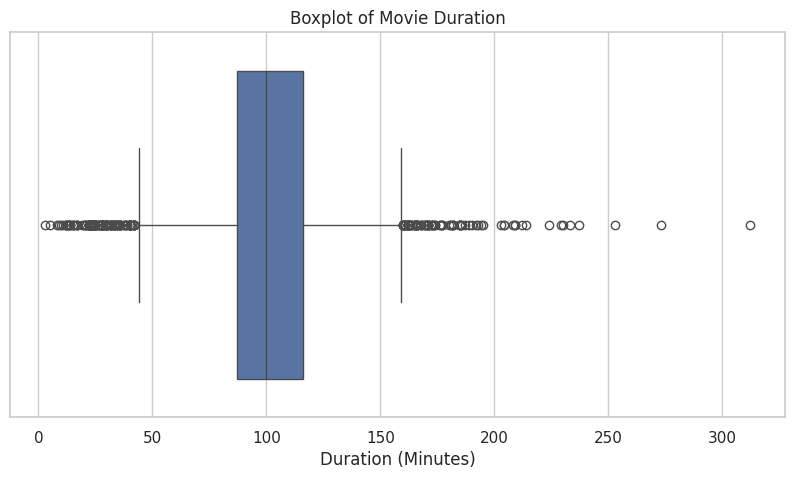

IQR: 29.0 minutes
Lower bound: 43.5, Upper bound: 159.5
Potential movie-duration outliers: 240


In [21]:
plt.figure(figsize=(10,5))
sns.boxplot(x=movies["duration_minutes"].dropna(), color="C0")
plt.title("Boxplot of Movie Duration")
plt.xlabel("Duration (Minutes)")
plt.show()

q1 = movies["duration_minutes"].quantile(0.25)
q3 = movies["duration_minutes"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr
outliers = movies[(movies["duration_minutes"] < lower) | (movies["duration_minutes"] > upper)]
print(f"IQR: {iqr:.1f} minutes")
print(f"Lower bound: {lower:.1f}, Upper bound: {upper:.1f}")
print("Potential movie-duration outliers:", len(outliers))

## 20. TV Show seasons analysis

count    1933.000000
mean        1.788929
std         1.565658
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: seasons, dtype: float64


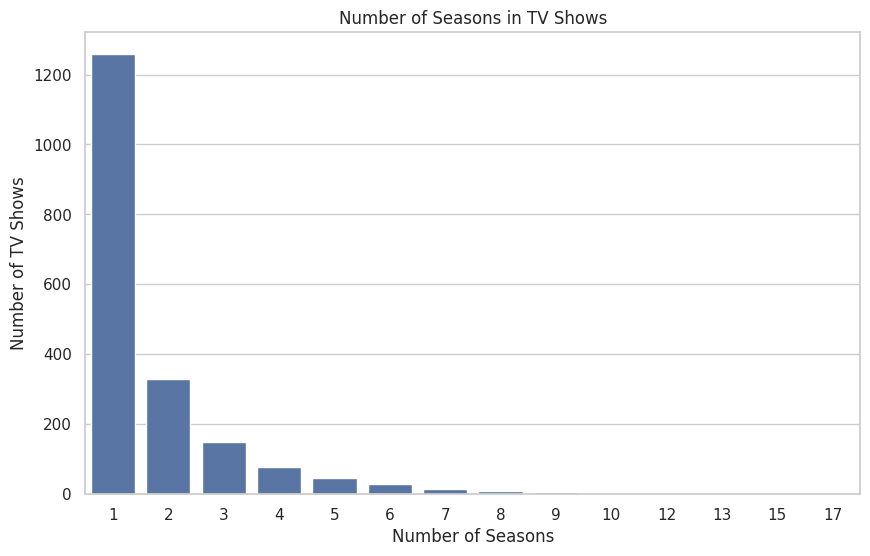

In [22]:
tv = netflix[netflix["type"] == "TV Show"].copy()
tv["seasons"] = pd.to_numeric(tv["duration"].str.extract(r"(\d+)")[0], errors="coerce")
print(tv["seasons"].describe())

plt.figure(figsize=(10,6))
sns.countplot(data=tv, x="seasons", color="C0")
plt.title("Number of Seasons in TV Shows")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.show()

## 21. Boxplot – TV Show seasons

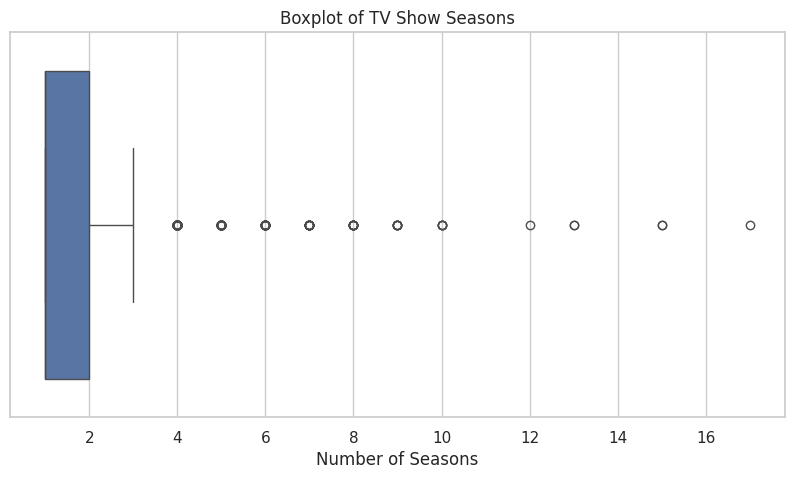

Q1=1.0, Median=1.0, Q3=2.0, IQR=1.0
Potential high-season outliers: 196


In [23]:
plt.figure(figsize=(10,5))
sns.boxplot(x=tv["seasons"].dropna(), color="C0")
plt.title("Boxplot of TV Show Seasons")
plt.xlabel("Number of Seasons")
plt.show()

q1 = tv["seasons"].quantile(0.25)
q3 = tv["seasons"].quantile(0.75)
iqr = q3-q1
upper = q3+1.5*iqr
print(f"Q1={q1}, Median={tv['seasons'].median()}, Q3={q3}, IQR={iqr}")
print("Potential high-season outliers:", (tv["seasons"]>upper).sum())

## 22. Actors – unnesting and frequency

cast
Takahiro Sakurai    26
Anupam Kher         25
Rajesh Kava         25
Julie Tejwani       24
Yuki Kaji           24
Jigna Bhardwaj      22
Rupa Bhimani        22
Vincent Tong        22
Daisuke Ono         20
Junichi Suwabe      20
Kareena Kapoor      19
Shah Rukh Khan      19
Boman Irani         18
Andrea Libman       18
John Cleese         18
Name: count, dtype: int64


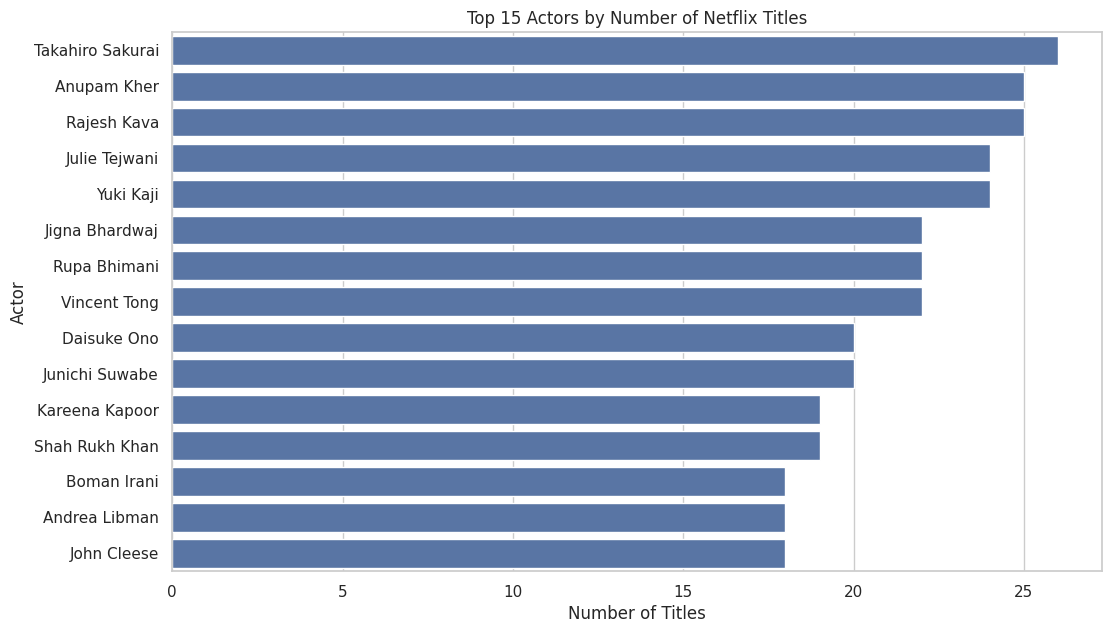

In [24]:
actor_df = netflix.copy()
actor_df["cast"] = actor_df["cast"].str.split(", ")
actor_df = actor_df.explode("cast")
actor_counts = actor_df[actor_df["cast"] != "Unknown"]["cast"].value_counts()
print(actor_counts.head(15))

plt.figure(figsize=(12,7))
a15 = actor_counts.head(15)
sns.barplot(x=a15.values, y=a15.index, color="C0")
plt.title("Top 15 Actors by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Actor")
plt.show()

## 23. Directors – unnesting and frequency

director
Rajiv Chilaka          19
Jan Suter              15
Suhas Kadav            15
Raúl Campos            14
Marcus Raboy           13
Cathy Garcia-Molina    12
Youssef Chahine        12
Jay Chapman             9
Don Michael Paul        8
Justin G. Dyck          8
Fernando Ayllón         8
Anurag Kashyap          8
Jay Karas               7
Hanung Bramantyo        7
Hidenori Inoue          7
Name: count, dtype: int64


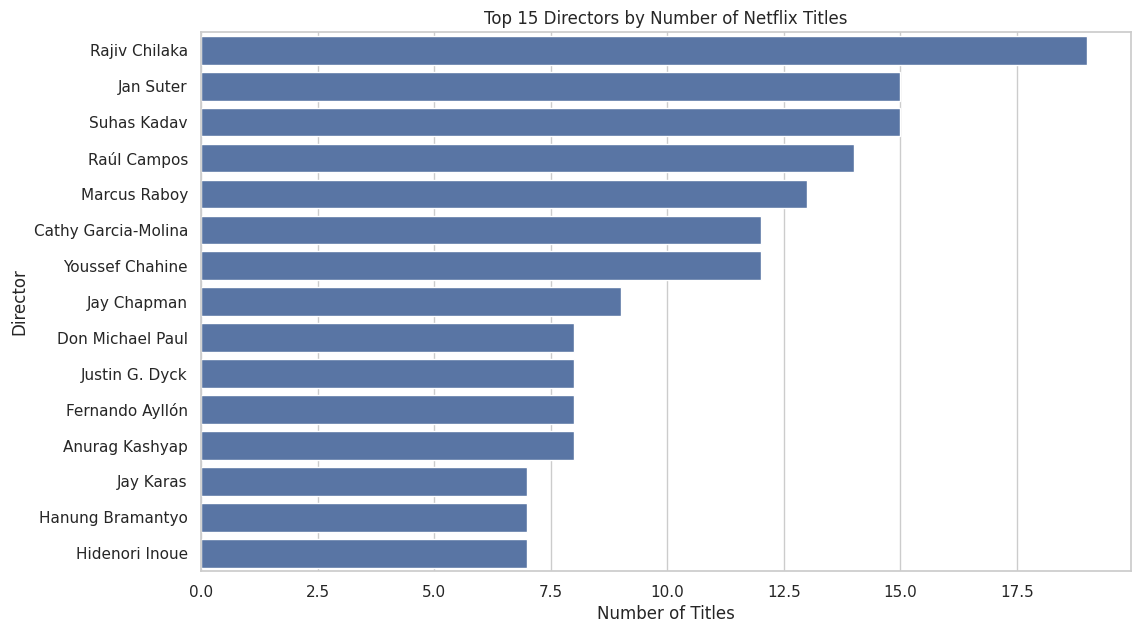

In [25]:
director_df = netflix.copy()
director_df["director"] = director_df["director"].str.split(", ")
director_df = director_df.explode("director")
director_counts = director_df[director_df["director"] != "Unknown"]["director"].value_counts()
print(director_counts.head(15))

plt.figure(figsize=(12,7))
d15 = director_counts.head(15)
sns.barplot(x=d15.values, y=d15.index, color="C0")
plt.title("Top 15 Directors by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.show()

## 24. Genre × content type

col_0                     Movie  TV Show  Total
row_0                                          
International Movies       1755        0   1755
Dramas                     1426        0   1426
Comedies                   1025        0   1025
International TV Shows        0     1000   1000
TV Dramas                     0      576    576
Action & Adventure          464        0    464
TV Comedies                   0      436    436
Romantic Movies             398        0    398
Documentaries               389        0    389
Children & Family Movies    377        0    377
Independent Movies          376        0    376
Crime TV Shows                0      349    349
Thrillers                   328        0    328
Kids' TV                      0      321    321
Romantic TV Shows             0      253    253


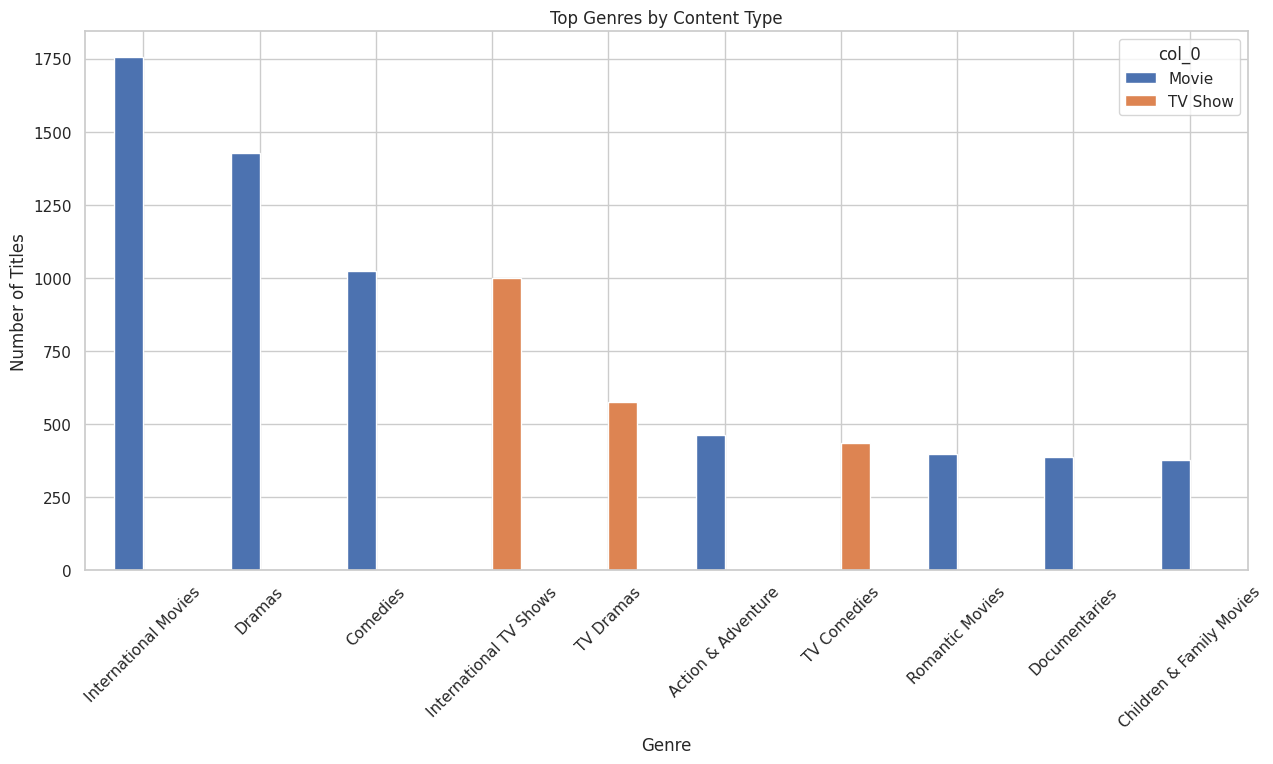

In [26]:
# Coerce Series to numpy arrays before crosstab to avoid reindexing on duplicate indexes
genre_type = pd.crosstab(genre_df["listed_in"].to_numpy(), genre_df["type"].to_numpy())
genre_type["Total"] = genre_type.sum(axis=1)
genre_type = genre_type.sort_values("Total", ascending=False)
print(genre_type.head(15))

gt = genre_type.head(10).drop(columns="Total")
gt.plot(kind="bar", figsize=(15,7))
plt.title("Top Genres by Content Type")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

## 25. Rating × content type

type    Movie  TV Sh  TV Show
rating                       
TV-MA    1308      0      938
TV-14     888      0      485
R         366      0        1
TV-PG     277      0      188
PG-13     226      0        0
PG        123      0        0
TV-Y      100      0      130
TV-G       83      0       61
TV-Y7      79      0      130
G          13      0        0


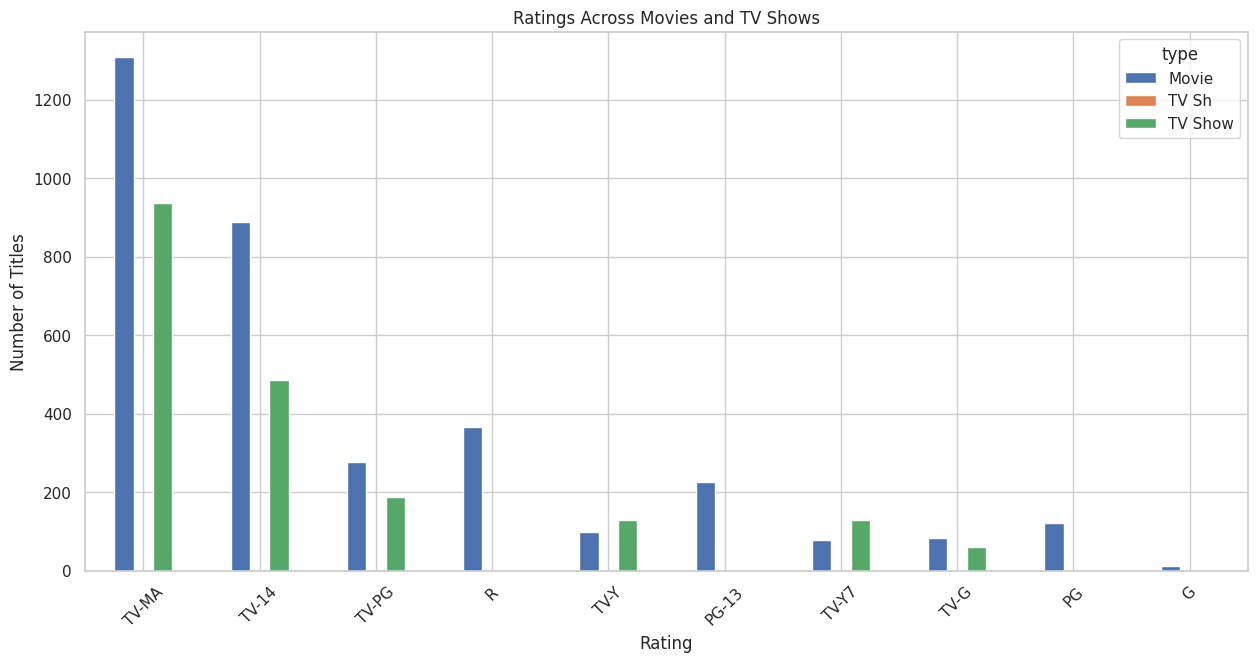

In [27]:
rating_type = pd.crosstab(netflix["rating"], netflix["type"])
print(rating_type.sort_values("Movie", ascending=False).head(10))

rt = rating_type.loc[rating_type.sum(axis=1).sort_values(ascending=False).head(10).index]
rt.plot(kind="bar", figsize=(15,7))
plt.title("Ratings Across Movies and TV Shows")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

## 26. Additional outlier and data-quality checks

In [28]:
print("Duplicate rows:", netflix.duplicated().sum())
print("Duplicate show IDs:", netflix["show_id"].duplicated().sum())
print("Release-year range:", netflix["release_year"].min(), "to", netflix["release_year"].max())
print("Movie duration min/max:", movies["duration_minutes"].min(), movies["duration_minutes"].max())
print("TV seasons min/max:", tv["seasons"].min(), tv["seasons"].max())

Duplicate rows: 0
Duplicate show IDs: 0
Release-year range: 1925.0 to 2021.0
Movie duration min/max: 3 312
TV seasons min/max: 1 17


# 27. Insights based on the analysis

### Range and distribution
- Release years range from **1925 to 2021**, with a median of **2017**.
- Movie duration ranges from **3 to 312 minutes**, with a median of **98 minutes**.
- TV Shows range from **1 to 17 seasons**, with a median of **1 season**.
- Movies make up about **69.6%** of all titles; TV Shows make up about **30.4%**.

### Missing values
- Director has the most missing observations (**2,634**), followed by country (**831**) and cast (**825**).
- Missing descriptive fields should not be treated as evidence that the corresponding content does not exist; they simply indicate unavailable metadata.

### Content mix
- Movies dominate the catalog overall.
- The gap between Movies and TV Shows narrows considerably in recent release years.
- TV Shows exceed Movies for release year **2021** in the available dataset (315 vs 277).

### Countries
- The **United States (3,689)** is the largest source of content.
- **India (1,046)** is second, showing strong international production potential.
- The United Kingdom, Canada, France, Japan, Spain and South Korea are also major contributors.

### Genres and ratings
- International Movies, Dramas, Comedies and International TV Shows are among the largest genre categories.
- TV-MA and TV-14 are the two most common ratings, indicating a strong mature/teen audience focus.

### Launch timing
- July is the month with the highest number of TV Shows added (**254**), followed by December (**250**) and September (**246**).
- This is a catalog-addition pattern, not a proof of audience or revenue performance.

### Actors and directors
- **Anupam Kher** is the most frequently appearing actor in the full cast-expanded dataset (43 titles).
- **Rajiv Chilaka** is the most frequently appearing director (22 titles).
- These frequencies describe catalog presence; they should not be interpreted as measures of quality or profitability without viewer-performance data.

# 28. Business Insights

1. **Netflix still has a movie-heavy catalog**, but the recent release mix shows a meaningful shift toward TV Shows.
2. **Recent content is strategically important**, with the catalog heavily concentrated in releases from the mid-2010s onward.
3. **International production is essential to Netflix's growth**, with strong contributions from India, the UK, Canada, France, Japan, Spain and South Korea.
4. **Local-language and international content are major parts of the catalog**, not a small niche.
5. **Drama and comedy have broad representation**, making them useful categories for both global and localized storytelling.
6. **Most TV Shows are short-running**, with a median of one season. Netflix has significant experience with limited-series formats.
7. **Most Movies are around 90–120 minutes**, providing a practical benchmark for standard feature-length productions.
8. **The dataset does not include business-performance metrics** such as views, watch time, subscriber acquisition or retention, so production decisions should combine these catalog findings with internal performance data.

# 29. Recommendations

1. **Continue growing high-quality TV content.** TV Shows have become more prominent among recent releases, so Netflix should maintain investment in strong episodic formats.

2. **Increase local-language production in priority markets.** India and several other non-US markets already have substantial content representation, creating a strong base for further localization.

3. **Use country-specific content plans.** The ideal mix of Movies, TV Shows and genres should be adapted to each market instead of using one global formula.

4. **Keep investing in drama, comedy and international storytelling.** These are among the largest categories in the catalog and provide room for both mainstream and local stories.

5. **Work with established local actors and directors.** Local talent can help make new productions more relevant to regional audiences.

6. **Maintain a consistent pipeline of fresh releases.** The strong growth in titles added after 2016 suggests that a steady flow of new content is central to Netflix's catalog strategy.

7. **Consider July, September and December as candidate TV-release windows.** These months have high TV Show addition activity historically, but the launch decision should be validated with actual audience-engagement data.

8. **Use viewer behavior before making large production investments.** Combine catalog trends with watch time, completion rate, subscriber acquisition, retention and revenue data.

# 30. Executive Summary

The analysis of **8,807 Netflix titles** shows that Movies dominate the overall catalog, but TV Shows have become increasingly important among recent releases. The dataset contains **6,131 Movies and 2,676 TV Shows**. In 2021, TV Shows exceed Movies by release-year count, indicating a meaningful recent shift toward episodic content.

The United States is the largest source of content, while India is the second-largest. This supports a continued focus on international and local-language production. International Movies, Dramas, Comedies and International TV Shows are among the strongest categories, showing the value of combining popular genres with localized storytelling.

Most Movies are around 90–120 minutes, while most TV Shows have one or two seasons, making shorter episodic formats an important part of Netflix's catalog. July is the most common month for TV Show additions in the available data, although the dataset cannot establish which month produces the best viewing or revenue outcomes.

Overall, Netflix should continue expanding high-quality TV content, strengthen local-language productions, tailor its content mix to individual countries, maintain a steady stream of new releases, and combine catalog analysis with actual viewer and subscriber-performance data before making major production decisions.